# **Stage 2 - Exploratory Data Analysis**

This section explores the cleaned FOODS dataset to understand demand patterns, seasonality, price effects, SNAP effects, event effects, and store-level differences. The goal is to identify important features that should be considered in later forecasting models.

In [1]:
#Import Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("outputs")
plt.rcParams.update({"figure.dpi": 110, "font.size": 12})

df = pd.read_parquet(OUT / "foods_clean.parquet")
print(df.shape)
df.head(3)

(21798313, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,d_num,date,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,1,2011-01-29,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.00
1,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,1,2011-01-29,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,7.88
2,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,1,2011-01-29,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.88


### 2.1 Scale & composition

~14.4K series across 1,437 products, 10 stores, 3 states; 45.9M units over
1,941 days.

In [2]:
# Dataset Scale & Overview
print("=== Modeling Target Scale ===")
print(f"Total Time Series (Product × Store): {df['id'].nunique():,}")
print(f"Unique Products:                     {df['item_id'].nunique():,}")
print(f"Unique Stores:                       {df['store_id'].nunique()}")
print(f"Unique States:                       {df['state_id'].nunique()}")
print(f"Time Horizon:                        {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Total Sales Volume (Units):          {df['sales'].sum():,}")
print(f"Total Observation Rows:              {len(df):,}")

=== Modeling Target Scale ===
Total Time Series (Product × Store): 14,370
Unique Products:                     1,437
Unique Stores:                       10
Unique States:                       3
Time Horizon:                        2011-01-29 → 2016-05-22
Total Sales Volume (Units):          45,922,427
Total Observation Rows:              21,798,313


**Sales by department** — Sales concentrate heavily in FOODS_3 (72%), with
FOODS_2 (17%) and FOODS_1 (11%) far smaller. FOODS_3 dominates and will drive
overall forecast quality.

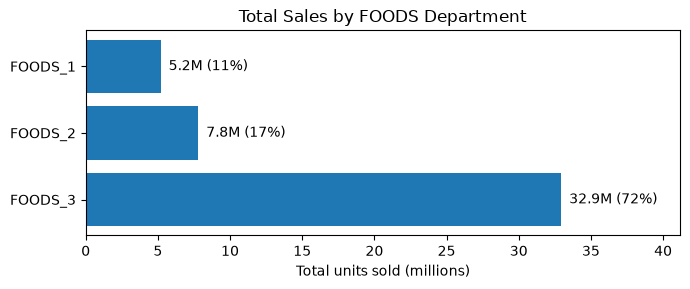

In [3]:
# Departmental composition
plt.style.use("default")
dept_sales = df.groupby("dept_id", observed=True)["sales"].sum().sort_values(ascending=False)
dept_share = dept_sales / dept_sales.sum() * 100

fig, ax = plt.subplots(figsize=(7, 3))
vals_m = dept_sales.values / 1e6
ax.barh(dept_sales.index.astype(str), vals_m)
ax.set_title("Total Sales by FOODS Department")
ax.set_xlabel("Total units sold (millions)")
ax.set_xlim(0, vals_m.max() * 1.25)
for i, (v, p) in enumerate(zip(vals_m, dept_share.values)):
    ax.text(v, i, f"  {v:.1f}M ({p:.0f}%)", va="center")

plt.tight_layout()
plt.show()

In [4]:
# Aggregate total sales by day
daily = df.groupby("date", observed=True)["sales"].sum().sort_index()
print("Days:", len(daily))
print("Mean daily total sales:", f"{daily.mean():,.0f}")
daily.head(3)

Days: 1941
Mean daily total sales: 23,659


date
2011-01-29    23178
2011-01-30    22758
2011-01-31    17174
Name: sales, dtype: int64

### 2.2 Trend & seasonality

**Total daily sales + 28-day MA** — A smooth upward trend with regular periodic
swings. This suggests that future forecasting models should include lag features, rolling averages, and time-based variables to capture trend and seasonality.

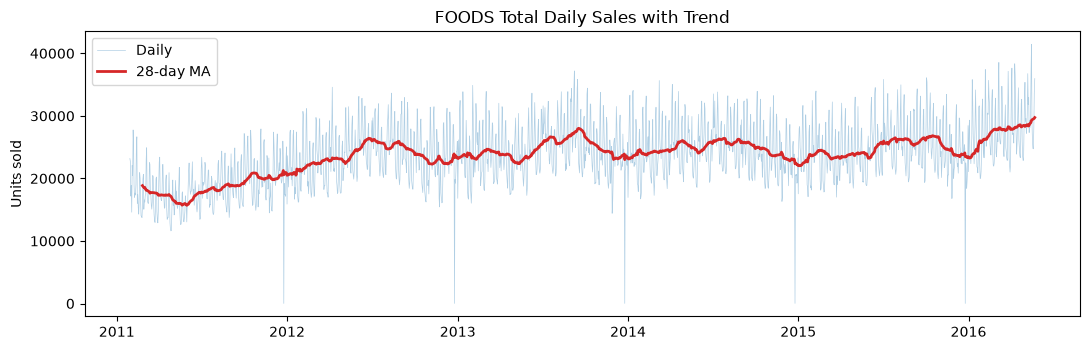

In [5]:
# Overall trend (supports argument 1: trend exists)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(daily.index, daily.values, lw=0.5, alpha=0.35, label="Daily")
ax.plot(daily.index, daily.rolling(28).mean(), lw=2, color="#d62728", label="28-day MA")
ax.set_title("FOODS Total Daily Sales with Trend")
ax.set_ylabel("Units sold")
ax.legend()
plt.tight_layout()
plt.show()

**Weekly seasonality** — Weekends (Sat/Sun) clearly exceed weekdays, with Tue–Thu
lowest. Weekday information should be included as an important calendar feature in the forecasting models.

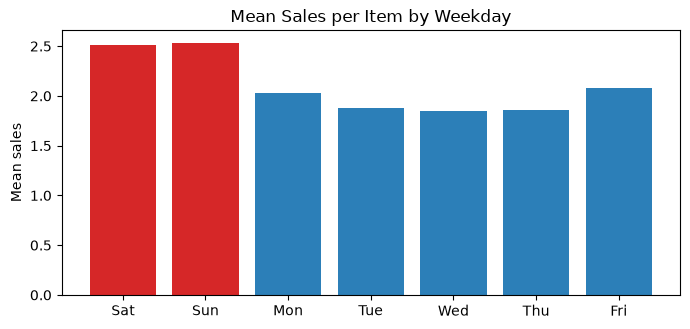

In [6]:
# Weekly seasonality
wday_names = {1:"Sat", 2:"Sun", 3:"Mon", 4:"Tue", 5:"Wed", 6:"Thu", 7:"Fri"}
wday_avg = df.groupby("wday", observed=True)["sales"].mean()

fig, ax = plt.subplots(figsize=(7, 3.4))
colors = ["#d62728" if w in (1, 2) else "#2c7fb8" for w in wday_avg.index]
ax.bar([wday_names[w] for w in wday_avg.index], wday_avg.values, color=colors)
ax.set_title("Mean Sales per Item by Weekday")
ax.set_ylabel("Mean sales")
plt.tight_layout()
plt.show()

**Monthly seasonality** — A yearly pattern with a summer peak and winter trough

This pattern may be related to consumer habits, holidays, and retail cycles, so month-level features should be included in the model.

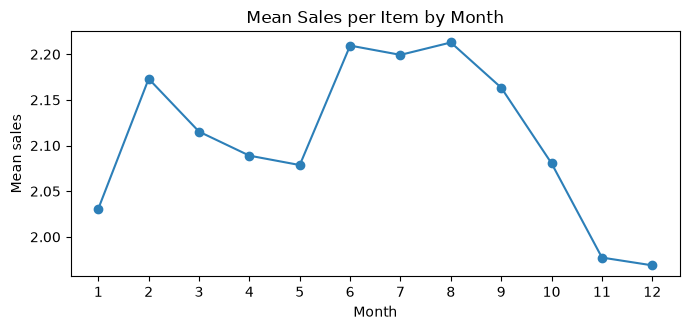

In [7]:
# Monthly seasonality
month_avg = df.groupby("month", observed=True)["sales"].mean()

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(month_avg.index, month_avg.values, marker="o", color="#2c7fb8")
ax.set_title("Mean Sales per Item by Month")
ax.set_xlabel("Month"); ax.set_ylabel("Mean sales"); ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

### 2.3 Intermittency

**Aggregate vs single-item demand**

The aggregate demand pattern is relatively smooth because it combines sales from many items and stores. However, the single product-store series is much more irregular and contains many zero-sales days. This shows that item-level forecasting is more challenging than aggregate forecasting and requires models that can handle intermittent demand.

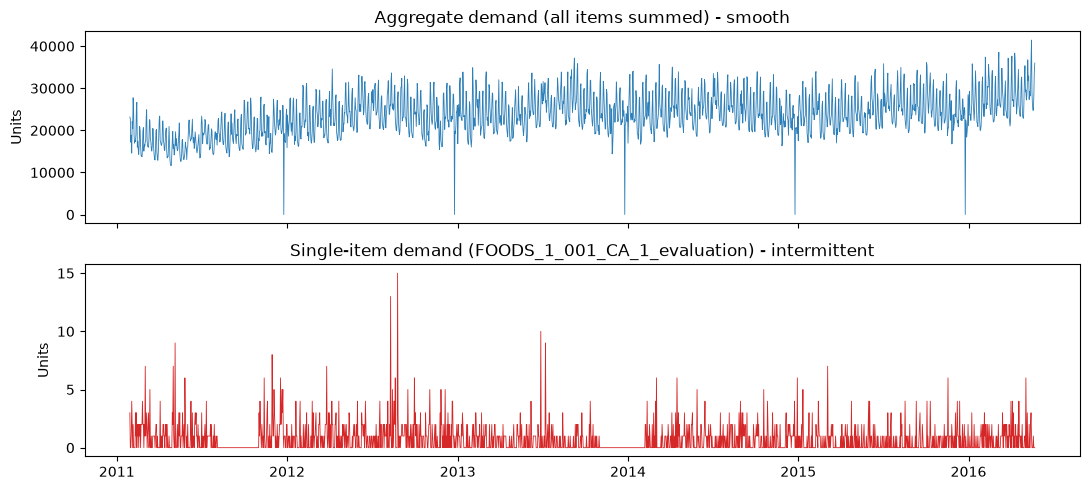

In [8]:
# Aggregate vs single-item demand
# Pick one representative item-store series
sample_id = df["id"].iloc[0]
one = df[df["id"] == sample_id].sort_values("date")

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(daily.index, daily.values, lw=0.6, color="#2c7fb8")
axes[0].set_title("Aggregate demand (all items summed) - smooth")
axes[0].set_ylabel("Units")

axes[1].plot(one["date"], one["sales"], lw=0.6, color="#d62728")
axes[1].set_title(f"Single-item demand ({sample_id}) - intermittent")
axes[1].set_ylabel("Units")
plt.tight_layout()
plt.show()

**Active-day ratio distribution**

The average active-day ratio is 47.7%, meaning that product-store series have positive sales on less than half of their observed days on average. The average zero-day ratio is 52.3%, which confirms that intermittent demand is a major characteristic of this dataset. This is important because models must handle many zero or low-sales observations.

In [9]:
# Zero-sales ratio across all series
# For each series: fraction of active days (sales > 0) over its own lifespan
series_stats = df.groupby("id", observed=True).agg(
    total_days=("sales", "size"),
    active_days=("sales", lambda s: (s > 0).sum()),
    total_sales=("sales", "sum"),
).reset_index()
series_stats["active_ratio"] = series_stats["active_days"] / series_stats["total_days"]
series_stats["zero_ratio"] = 1 - series_stats["active_ratio"]

print(f"Mean active-day ratio: {series_stats['active_ratio'].mean()*100:.1f}%")
print(f"Mean zero-day ratio:   {series_stats['zero_ratio'].mean()*100:.1f}%")
print(f"Series active <20% of days: {(series_stats['active_ratio'] < 0.2).mean()*100:.1f}%")
print(f"Series active >80% of days: {(series_stats['active_ratio'] > 0.8).mean()*100:.1f}%")

Mean active-day ratio: 47.7%
Mean zero-day ratio:   52.3%
Series active <20% of days: 10.8%
Series active >80% of days: 9.2%


### 2.4 Demand drivers

**Price vs demand**

This scatter plot compares average selling price with average daily demand for each product-store series. The correlation between price and log-demand is -0.3, suggesting that lower-priced items tend to have higher average demand. However, this relationship should not be interpreted as purely causal because product popularity, promotions, and store differences may also affect sales. Thus price must be modeled jointly with other features, not alone.

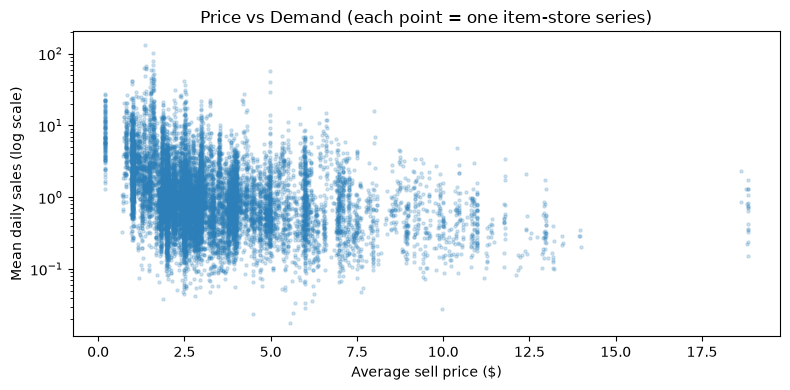

Correlation (price vs log-demand): -0.300


In [18]:
# Price vs demand
# Aggregate to item-store level: mean price and mean daily sales
price_demand = df.groupby("id", observed=True).agg(
    avg_price=("sell_price", "mean"),
    mean_sales=("sales", "mean"),
).reset_index()
price_demand = price_demand[price_demand["mean_sales"] > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(price_demand["avg_price"], price_demand["mean_sales"],
           s=5, alpha=0.2, color="#2c7fb8")
ax.set_yscale("log")
ax.set_xlabel("Average sell price ($)")
ax.set_ylabel("Mean daily sales (log scale)")
ax.set_title("Price vs Demand (each point = one item-store series)")
plt.tight_layout(); plt.show()

corr = np.corrcoef(price_demand["avg_price"], np.log1p(price_demand["mean_sales"]))[0, 1]
print(f"Correlation (price vs log-demand): {corr:.3f}")

**SNAP effect**

SNAP days are compared with non-SNAP days to evaluate their relationship with average sales. The result shows that sales on SNAP days are **+17.5%** vs non-SNAP days. , suggesting that SNAP may be an important external demand driver. Therefore, the SNAP indicator should be included as a forecasting feature.

In [13]:
# rebuild single snap column from per-state columns
df["snap"] = np.select(
    [df["state_id"] == "CA", df["state_id"] == "TX", df["state_id"] == "WI"],
    [df["snap_CA"], df["snap_TX"], df["snap_WI"]],
    default=0,
).astype("int8")

# drop the three per-state columns now that we have a single snap
df = df.drop(columns=["snap_CA", "snap_TX", "snap_WI"])

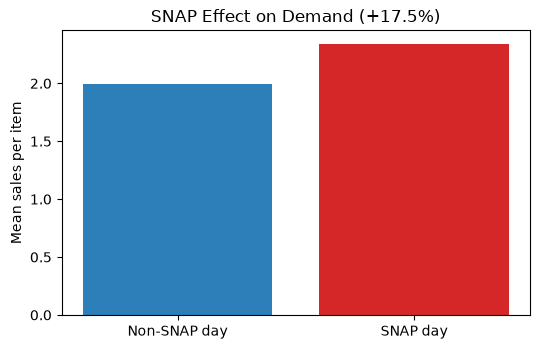

Non-SNAP: 1.992 | SNAP: 2.341 | Lift: +17.5%


In [14]:
# SNAP effect
snap_effect = df.groupby("snap", observed=True)["sales"].mean()
lift = (snap_effect[1] / snap_effect[0] - 1) * 100

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.bar(["Non-SNAP day", "SNAP day"], [snap_effect[0], snap_effect[1]],
       color=["#2c7fb8", "#d62728"])
ax.set_ylabel("Mean sales per item")
ax.set_title(f"SNAP Effect on Demand (+{lift:.1f}%)")
plt.tight_layout(); plt.show()
print(f"Non-SNAP: {snap_effect[0]:.3f} | SNAP: {snap_effect[1]:.3f} | Lift: +{lift:.1f}%")

**Event and Holiday Effect**

By comparing sales between normal days and event days, the results show that event days have only a limited overall impact on customer purchasing behavior. However, different event types appear to affect demand in different directions. This suggests that holiday and event variables may still help the forecasting models capture short-term demand changes.

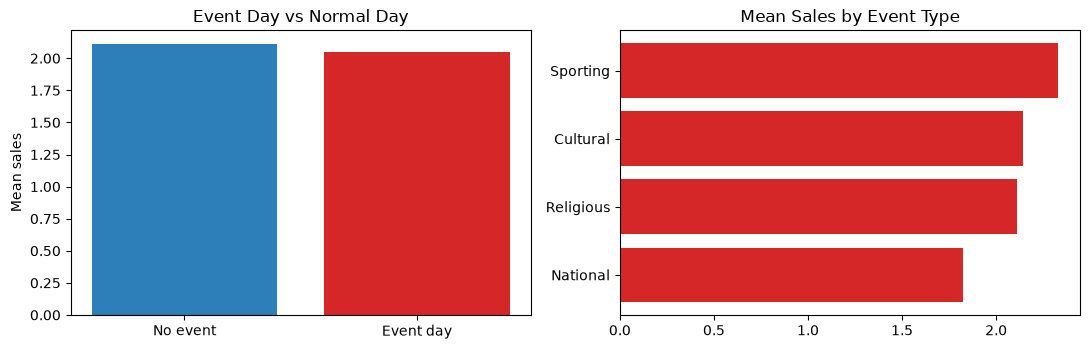

event_type_1
National     1.821830
Religious    2.112847
Cultural     2.144219
Sporting     2.329144
Name: sales, dtype: float64


In [15]:
# Event / holiday effect
df["has_event"] = df["event_name_1"].notna()
event_effect = df.groupby("has_event", observed=True)["sales"].mean()

# By event type
type_effect = df[df["event_name_1"].notna()].groupby(
    "event_type_1", observed=True)["sales"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(["No event", "Event day"], [event_effect[False], event_effect[True]],
            color=["#2c7fb8", "#d62728"])
axes[0].set_title("Event Day vs Normal Day"); axes[0].set_ylabel("Mean sales")

axes[1].barh(type_effect.index.astype(str), type_effect.values, color="#d62728")
axes[1].set_title("Mean Sales by Event Type")
plt.tight_layout(); plt.show()
print(type_effect)

### 2.5 Heterogeneity

**Store-Level Demand Differences**

Average daily sales differ noticeably across stores. This shows that demand is strongly affected by store location and regional market conditions.Store identity itself is a strong predictor.

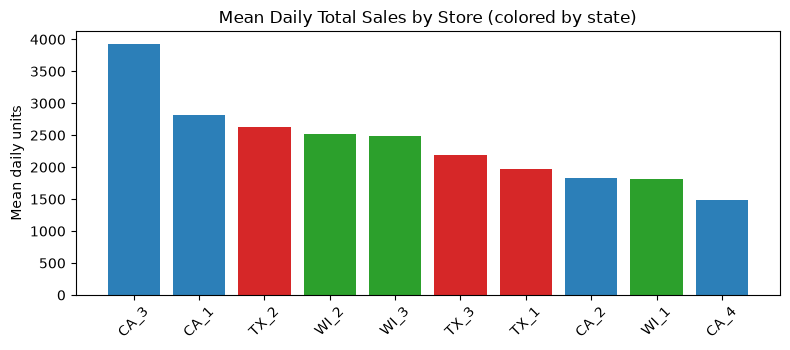

Largest store: CA_3 (3929/day)
Smallest store: CA_4 (1479/day)
Ratio: 2.7x


In [16]:
# State and store heterogeneity
store_daily = df.groupby(["store_id", "date"], observed=True)["sales"].sum().reset_index()
store_avg = store_daily.groupby("store_id", observed=True)["sales"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.6))
state_color = {"CA": "#2c7fb8", "TX": "#d62728", "WI": "#2ca02c"}
colors = [state_color[s.split("_")[0]] for s in store_avg.index]
ax.bar(store_avg.index.astype(str), store_avg.values, color=colors)
ax.set_title("Mean Daily Total Sales by Store (colored by state)")
ax.set_ylabel("Mean daily units")
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

print("Largest store:", store_avg.idxmax(), f"({store_avg.max():.0f}/day)")
print("Smallest store:", store_avg.idxmin(), f"({store_avg.min():.0f}/day)")
print("Ratio:", f"{store_avg.max()/store_avg.min():.1f}x")

**Cross-Store Variation by Item**

This analysis examines how much the same item’s average sales vary across stores. A high coefficient of variation means that the same product can perform very differently depending on the store. This supports the need to model both item-level and store-level effects rather than relying only on overall product demand.

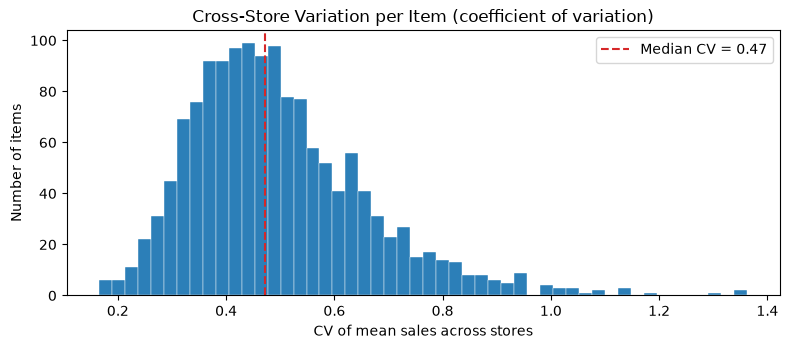

Median CV across stores: 0.47
Items with CV > 0.5 (high cross-store variation): 42%


In [17]:
# cross-store variation is widespread
# For each item, how much does its mean sales vary across stores?
item_store = df.groupby(["item_id", "store_id"], observed=True)["sales"].mean().reset_index()
cv = item_store.groupby("item_id", observed=True)["sales"].agg(
    lambda s: s.std() / s.mean() if s.mean() > 0 else np.nan
).dropna()

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(cv, bins=50, color="#2c7fb8", edgecolor="white", linewidth=0.3)
ax.axvline(cv.median(), color="#d62728", ls="--", label=f"Median CV = {cv.median():.2f}")
ax.set_title("Cross-Store Variation per Item (coefficient of variation)")
ax.set_xlabel("CV of mean sales across stores"); ax.set_ylabel("Number of items")
ax.legend()
plt.tight_layout(); plt.show()
print(f"Median CV across stores: {cv.median():.2f}")
print(f"Items with CV > 0.5 (high cross-store variation): {(cv > 0.5).mean()*100:.0f}%")